# 03 - SARIMA

Building on notebook 02's baselines (Seasonal Naive: 8.29% MAPE is the benchmark to
beat). SARIMA models the series using its own past values, which only works validly if
the series is stationary -- so before picking any model parameters, we test for that
formally, then difference the series until it holds.

This notebook:
1. Rebuilds the statewide weekly series and the identical train/test split from notebook 02
2. Tests the training data for stationarity (ADF and KPSS)
3. Differences the series until it's stationary, re-testing after each step
4. Reads ACF/PACF to select SARIMA's (p,d,q)(P,D,Q,s) orders
5. Fits, forecasts the 52-week holdout, and evaluates with the same MAPE/RMSE/MAE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

df = pd.read_csv("../data/raw/weekly_sales_by_category.csv", parse_dates=["week_start"])

statewide = df.groupby("week_start")["total_sales_dollars"].sum().reset_index()
statewide.columns = ["week_start", "total_sales"]
statewide = statewide.sort_values("week_start").reset_index(drop=True)

TEST_WEEKS = 52
train = statewide.iloc[:-TEST_WEEKS].copy()
test = statewide.iloc[-TEST_WEEKS:].copy()

y_train = train["total_sales"].values
y_test = test["total_sales"].values

print(f"Train: {len(train)} weeks, {train['week_start'].min().date()} to {train['week_start'].max().date()}")
print(f"Test:  {len(test)} weeks, {test['week_start'].min().date()} to {test['week_start'].max().date()}")

Train: 435 weeks, 2017-01-02 to 2025-04-28
Test:  52 weeks, 2025-05-05 to 2026-04-27


## Stationarity check

Testing on **training data only** -- not the full series. Any decision about how to
difference this data has to be made without looking at the test period, or we'd be
leaking test information into the model before it's even fit.

Running both tests, since they can disagree and that disagreement itself is informative:

- **ADF** (Augmented Dickey-Fuller): null hypothesis = "non-stationary." A small
  p-value (< 0.05) lets us reject that and conclude stationary.
- **KPSS**: null hypothesis is the opposite = "stationary." A small p-value (< 0.05)
  means we reject *that* and conclude non-stationary.

In [2]:
adf_result = adfuller(y_train, autolag="AIC")
print("=== ADF Test ===")
print("Statistic:", round(adf_result[0], 4))
print("p-value:", round(adf_result[1], 4))
print("Stationary by ADF (p < 0.05)?", adf_result[1] < 0.05)

kpss_result = kpss(y_train, regression="c", nlags="auto")
print()
print("=== KPSS Test ===")
print("Statistic:", round(kpss_result[0], 4))
print("p-value:", round(kpss_result[1], 4))
print("Stationary by KPSS (p > 0.05)?", kpss_result[1] > 0.05)

=== ADF Test ===
Statistic: -2.449
p-value: 0.1284
Stationary by ADF (p < 0.05)? False

=== KPSS Test ===
Statistic: 2.9469
p-value: 0.01
Stationary by KPSS (p > 0.05)? False


/var/folders/p8/j5d3s5jx5vz8pfxrz5qz98rw0000gn/T/ipykernel_54161/2952962122.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(y_train, regression="c", nlags="auto")


## First-order differencing

Removing the trend first: instead of modeling the level of sales each week, model the
*week-over-week change*. If a trend is the main problem, this alone might be enough to
pass both tests -- if not, we'll still have the yearly seasonality left to deal with
separately.

In [3]:
y_train_diff1 = np.diff(y_train, n=1)

print("Length after differencing:", len(y_train_diff1), "(was", len(y_train), "-- lost 1 observation, expected)")
print()

adf_diff1 = adfuller(y_train_diff1, autolag="AIC")
print("=== ADF Test (after 1st differencing) ===")
print("Statistic:", round(adf_diff1[0], 4))
print("p-value:", round(adf_diff1[1], 4))
print("Stationary by ADF (p < 0.05)?", adf_diff1[1] < 0.05)

kpss_diff1 = kpss(y_train_diff1, regression="c", nlags="auto")
print()
print("=== KPSS Test (after 1st differencing) ===")
print("Statistic:", round(kpss_diff1[0], 4))
print("p-value:", round(kpss_diff1[1], 4))
print("Stationary by KPSS (p > 0.05)?", kpss_diff1[1] > 0.05)

Length after differencing: 434 (was 435 -- lost 1 observation, expected)

=== ADF Test (after 1st differencing) ===
Statistic: -7.5938
p-value: 0.0
Stationary by ADF (p < 0.05)? True

=== KPSS Test (after 1st differencing) ===
Statistic: 0.2271
p-value: 0.1
Stationary by KPSS (p > 0.05)? True


/var/folders/p8/j5d3s5jx5vz8pfxrz5qz98rw0000gn/T/ipykernel_54161/2414778627.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff1 = kpss(y_train_diff1, regression="c", nlags="auto")


## ACF / PACF on the differenced series

The ADF/KPSS tests above confirm the differenced series has no trend left -- but they
don't tell us whether the yearly seasonality (Dec high, Jan low, from notebook 01) is
still present as autocorrelation. For that we check the ACF specifically at lag 52 and
104 (one and two years back, in weekly data). A real spike there means we still need
seasonal terms even though the series is technically "stationary."

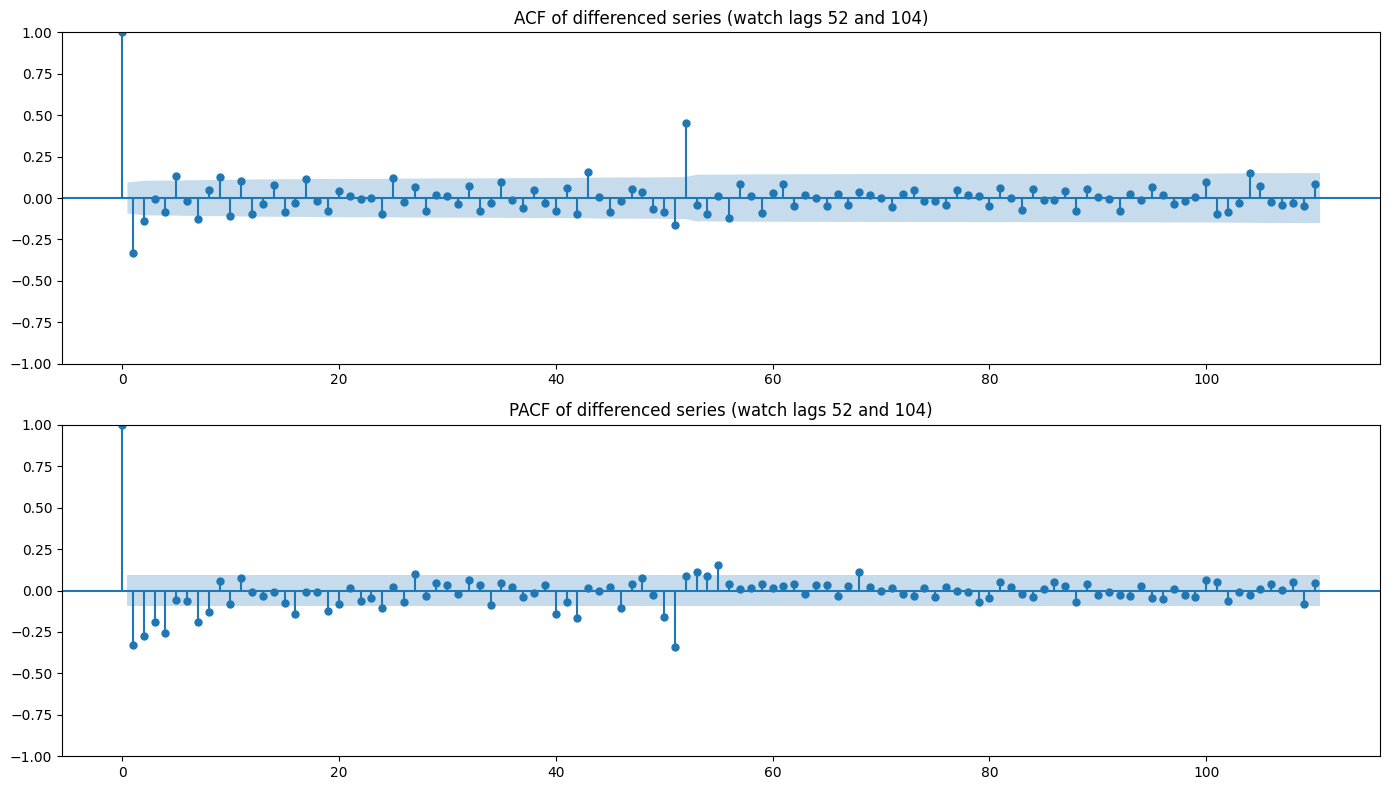

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(y_train_diff1, lags=110, ax=axes[0])
axes[0].set_title("ACF of differenced series (watch lags 52 and 104)")
plot_pacf(y_train_diff1, lags=110, ax=axes[1], method="ywm")
axes[1].set_title("PACF of differenced series (watch lags 52 and 104)")
plt.tight_layout()
plt.show()

## Seasonal differencing

The lag-52 spike in both ACF and PACF confirms yearly seasonality survived regular
differencing. Applying a seasonal difference -- subtracting each value from the one
exactly 52 weeks earlier -- on top of the already-differenced series, then re-checking
ADF/KPSS and re-plotting ACF/PACF to see if that spike is gone.

In [5]:
def seasonal_diff(series, lag=52):
    return series[lag:] - series[:-lag]

y_train_diff1_52 = seasonal_diff(y_train_diff1, lag=52)
print("Length after regular + seasonal differencing:", len(y_train_diff1_52), 
      "(was", len(y_train_diff1), "-- lost 52 more observations, one full seasonal cycle)")
print()

adf_diff2 = adfuller(y_train_diff1_52, autolag="AIC")
print("=== ADF Test (after regular + seasonal differencing) ===")
print("Statistic:", round(adf_diff2[0], 4))
print("p-value:", round(adf_diff2[1], 4))
print("Stationary by ADF (p < 0.05)?", adf_diff2[1] < 0.05)

kpss_diff2 = kpss(y_train_diff1_52, regression="c", nlags="auto")
print()
print("=== KPSS Test (after regular + seasonal differencing) ===")
print("Statistic:", round(kpss_diff2[0], 4))
print("p-value:", round(kpss_diff2[1], 4))
print("Stationary by KPSS (p > 0.05)?", kpss_diff2[1] > 0.05)

Length after regular + seasonal differencing: 382 (was 434 -- lost 52 more observations, one full seasonal cycle)

=== ADF Test (after regular + seasonal differencing) ===
Statistic: -7.9208
p-value: 0.0
Stationary by ADF (p < 0.05)? True

=== KPSS Test (after regular + seasonal differencing) ===
Statistic: 0.1756
p-value: 0.1
Stationary by KPSS (p > 0.05)? True


/var/folders/p8/j5d3s5jx5vz8pfxrz5qz98rw0000gn/T/ipykernel_54161/3709155861.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff2 = kpss(y_train_diff1_52, regression="c", nlags="auto")


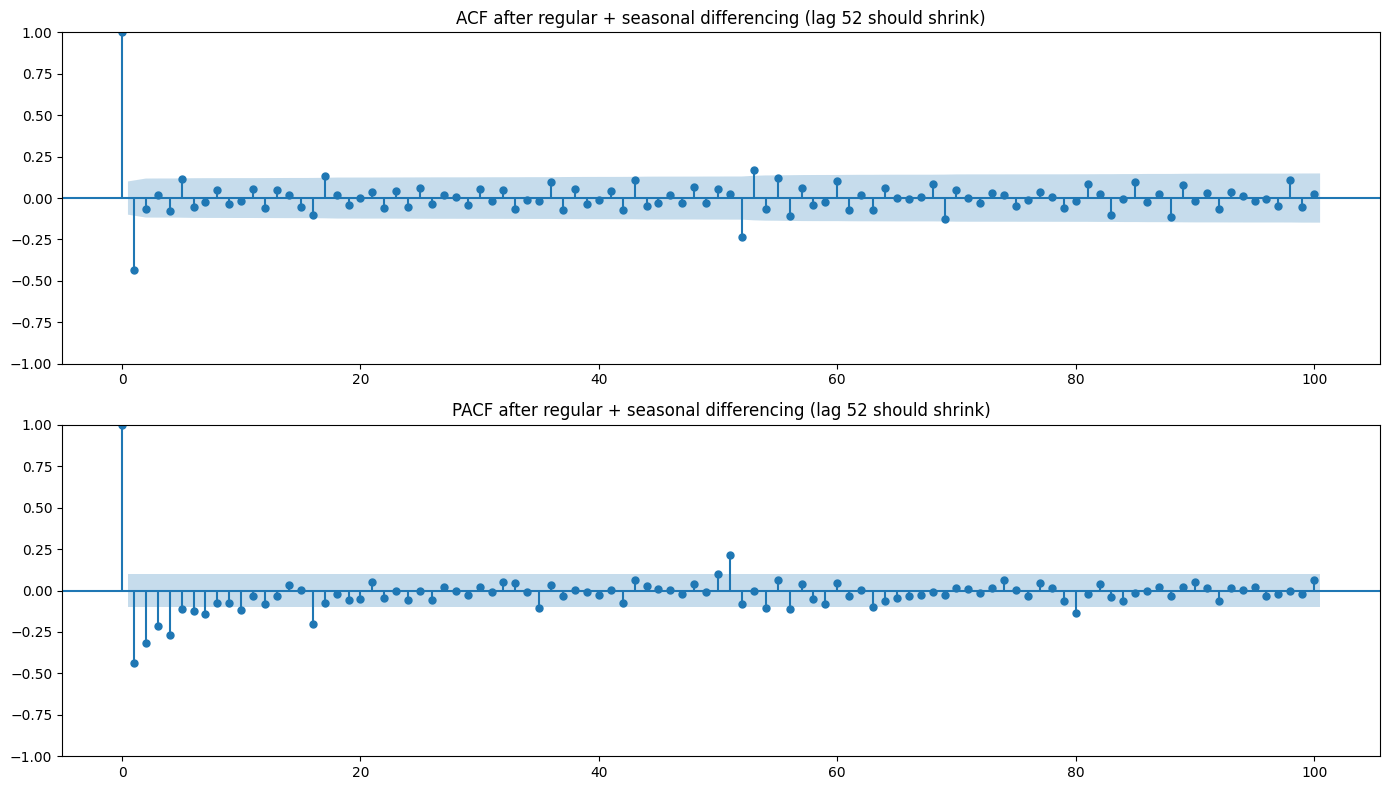

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(y_train_diff1_52, lags=100, ax=axes[0])
axes[0].set_title("ACF after regular + seasonal differencing (lag 52 should shrink)")
plot_pacf(y_train_diff1_52, lags=100, ax=axes[1], method="ywm")
axes[1].set_title("PACF after regular + seasonal differencing (lag 52 should shrink)")
plt.tight_layout()
plt.show()

## Model order selection via grid search on AIC

The ACF/PACF gave strong signal for d=1, D=1, s=52, and a hint toward a non-seasonal
MA(1) term -- but left the exact seasonal P/Q ambiguous, which is common with only ~8
seasonal cycles of data to read from. Rather than force a guess from the plot, we fit
several candidate (p,q)(P,Q) combinations with d/D/s fixed, and pick whichever scores
best on AIC (Akaike Information Criterion) -- a metric that rewards better fit but
penalizes extra parameters, the same "does the complexity earn its keep" philosophy
we used comparing models against the baselines.

In [7]:
import itertools
import time
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

p_values = range(0, 3)
q_values = range(0, 3)
P_values = range(0, 2)
Q_values = range(0, 2)
d, D, s = 1, 1, 52

combos = list(itertools.product(p_values, q_values, P_values, Q_values))
print(f"Fitting {len(combos)} candidate models, this can take several minutes...")
print()

search_results = []
start = time.time()
for i, (p, q, P, Q) in enumerate(combos, 1):
    t0 = time.time()
    try:
        model = SARIMAX(
            y_train,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False)
        aic = fit.aic
    except Exception:
        aic = np.nan
    elapsed = time.time() - t0
    aic_str = f"{aic:.1f}" if aic == aic else "FAILED"
    print(f"[{i}/{len(combos)}] order=({p},{d},{q}) seasonal=({P},{D},{Q},{s})  AIC={aic_str}  ({elapsed:.1f}s)")
    search_results.append({"order": (p, d, q), "seasonal_order": (P, D, Q, s), "AIC": aic})

print()
print(f"Total time: {(time.time()-start)/60:.1f} minutes")

search_df = pd.DataFrame(search_results).sort_values("AIC").reset_index(drop=True)
search_df.head(10)

Fitting 36 candidate models, this can take several minutes...

[1/36] order=(0,1,0) seasonal=(0,1,0,52)  AIC=11667.5  (0.4s)
[2/36] order=(0,1,0) seasonal=(0,1,1,52)  AIC=10033.2  (9.5s)
[3/36] order=(0,1,0) seasonal=(1,1,0,52)  AIC=10106.4  (2.1s)
[4/36] order=(0,1,0) seasonal=(1,1,1,52)  AIC=10002.3  (10.7s)
[5/36] order=(0,1,1) seasonal=(0,1,0,52)  AIC=11478.8  (1.2s)
[6/36] order=(0,1,1) seasonal=(0,1,1,52)  AIC=9866.7  (7.4s)
[7/36] order=(0,1,1) seasonal=(1,1,0,52)  AIC=9951.7  (7.8s)
[8/36] order=(0,1,1) seasonal=(1,1,1,52)  AIC=9862.1  (19.9s)
[9/36] order=(0,1,2) seasonal=(0,1,0,52)  AIC=11443.0  (1.9s)
[10/36] order=(0,1,2) seasonal=(0,1,1,52)  AIC=9827.9  (12.0s)
[11/36] order=(0,1,2) seasonal=(1,1,0,52)  AIC=9948.3  (11.6s)
[12/36] order=(0,1,2) seasonal=(1,1,1,52)  AIC=9823.4  (26.8s)
[13/36] order=(1,1,0) seasonal=(0,1,0,52)  AIC=11585.8  (0.5s)
[14/36] order=(1,1,0) seasonal=(0,1,1,52)  AIC=9976.3  (7.5s)
[15/36] order=(1,1,0) seasonal=(1,1,0,52)  AIC=10010.1  (5.3s)
[16

,order,seasonal_order,AIC
0,"(1, 1, 2)","(1, 1, 1, 52)",9816.902577
1,"(2, 1, 2)","(1, 1, 1, 52)",9818.597413
2,"(1, 1, 2)","(0, 1, 1, 52)",9822.578967
3,"(0, 1, 2)","(1, 1, 1, 52)",9823.436113
4,"(2, 1, 2)","(0, 1, 1, 52)",9824.382583
5,"(0, 1, 2)","(0, 1, 1, 52)",9827.897843
6,"(0, 1, 1)","(1, 1, 1, 52)",9862.146510
7,"(2, 1, 1)","(1, 1, 1, 52)",9862.559292
8,"(1, 1, 1)","(1, 1, 1, 52)",9862.882170
9,"(0, 1, 1)","(0, 1, 1, 52)",9866.719944


## Model order selection

Grid search over p,q in [0,2] and P,Q in [0,1], with d=1, D=1, s=52 fixed from the
earlier stationarity diagnostics, scored on AIC.

**Winner: SARIMA(1,1,2)(1,1,1,52)**, AIC = 9816.90 -- narrowly beats (2,1,2)(1,1,1,52)
at AIC = 9818.60, and does so with fewer parameters, so no parsimony trade-off needed.

Notably, this differs from the informal ACF/PACF read (which suggested q=1) -- the
grid search corrected that guess rather than confirming it, which is exactly why we
didn't commit to an order from the plot alone.

## Fitting the final model

Same order as the grid search winner, but this time without the relaxed
`enforce_stationarity`/`enforce_invertibility` settings. Those were a pragmatic choice
to keep the search from failing across 36 combinations -- for the model we're actually
going to trust and forecast with, we want those constraints enforced properly. If this
specific order can't fit cleanly under normal constraints, that itself would be a sign
to reconsider it.

In [8]:
final_order = (1, 1, 2)
final_seasonal_order = (1, 1, 1, 52)

final_model = SARIMAX(y_train, order=final_order, seasonal_order=final_seasonal_order)
final_fit = final_model.fit(disp=False)
print(final_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  435
Model:             SARIMAX(1, 1, 2)x(1, 1, [1], 52)   Log Likelihood               -5746.574
Date:                              Thu, 03 Sep 2026   AIC                          11505.148
Time:                                      18:58:59   BIC                          11528.821
Sample:                                           0   HQIC                         11514.540
                                              - 435                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9490      0.030    -31.665      0.000      -1.008      -0.890
ma.L1          0.36

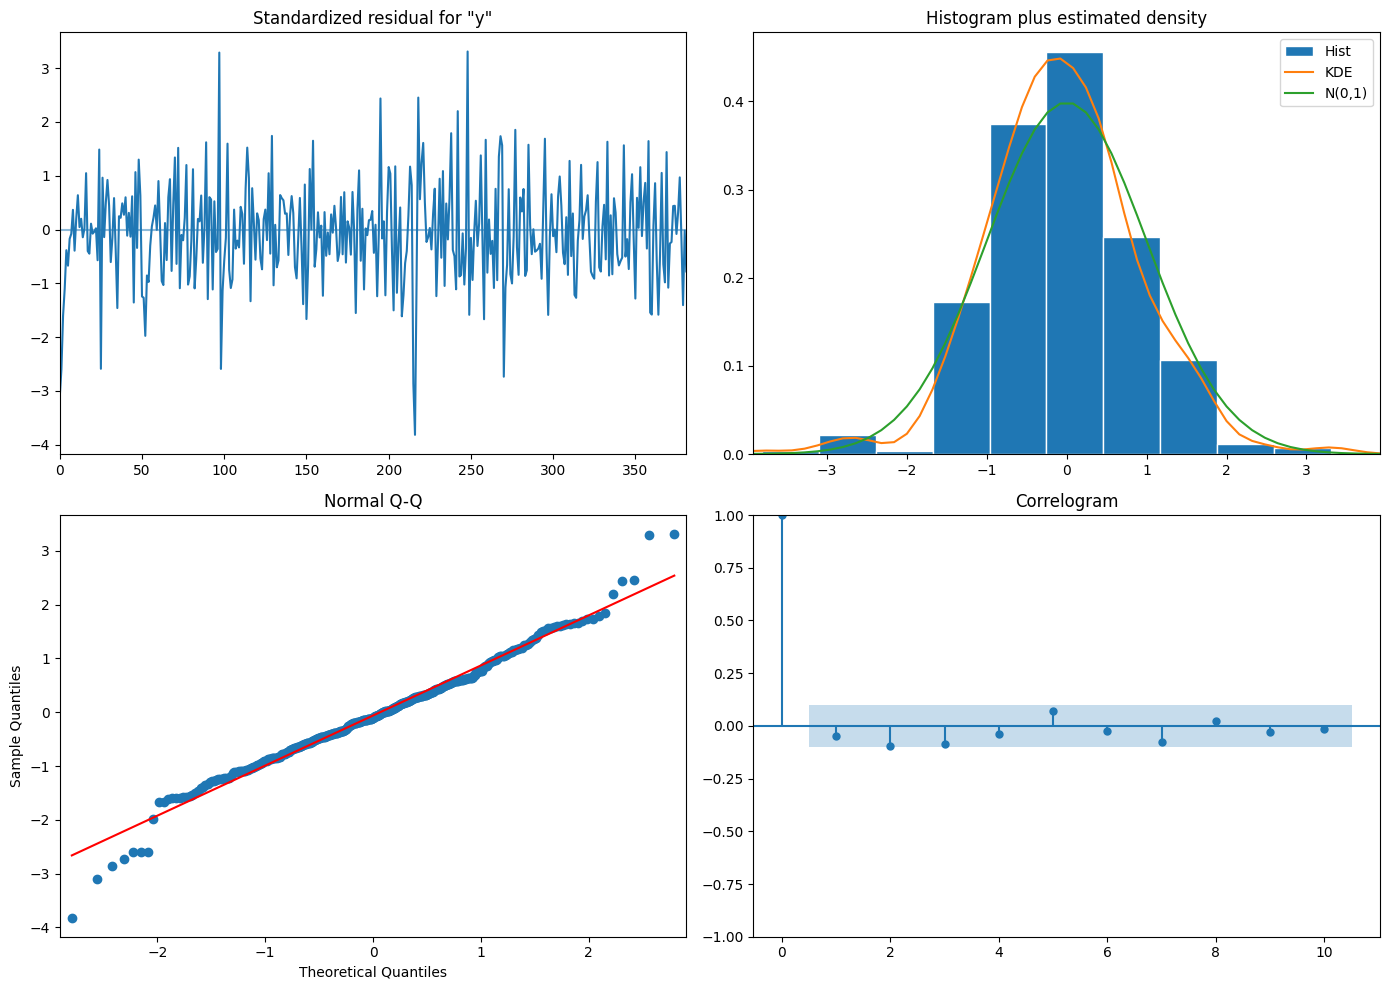

In [9]:
final_fit.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

In [10]:
candidates = search_df.head(5)[["order", "seasonal_order"]].values.tolist()

print("Re-fitting top 5 candidates with proper (enforced) constraints for a fair comparison:\n")

refit_results = []
for order, seasonal_order in candidates:
    try:
        m = SARIMAX(y_train, order=order, seasonal_order=seasonal_order)
        f = m.fit(disp=False)
        refit_results.append({"order": order, "seasonal_order": seasonal_order, "AIC_enforced": f.aic})
        print(f"order={order}  seasonal={seasonal_order}  AIC={f.aic:.1f}")
    except Exception as e:
        refit_results.append({"order": order, "seasonal_order": seasonal_order, "AIC_enforced": np.nan})
        print(f"order={order}  seasonal={seasonal_order}  FAILED: {e}")

refit_df = pd.DataFrame(refit_results).sort_values("AIC_enforced").reset_index(drop=True)
refit_df

Re-fitting top 5 candidates with proper (enforced) constraints for a fair comparison:

order=(1, 1, 2)  seasonal=(1, 1, 1, 52)  AIC=11505.1
order=(2, 1, 2)  seasonal=(1, 1, 1, 52)  AIC=11506.6
order=(1, 1, 2)  seasonal=(0, 1, 1, 52)  AIC=11520.7
order=(0, 1, 2)  seasonal=(1, 1, 1, 52)  AIC=11508.6
order=(2, 1, 2)  seasonal=(0, 1, 1, 52)  AIC=11522.1


,order,seasonal_order,AIC_enforced
0,"(1, 1, 2)","(1, 1, 1, 52)",11505.148333
1,"(2, 1, 2)","(1, 1, 1, 52)",11506.574250
2,"(0, 1, 2)","(1, 1, 1, 52)",11508.569550
3,"(1, 1, 2)","(0, 1, 1, 52)",11520.656622
4,"(2, 1, 2)","(0, 1, 1, 52)",11522.111355


In [11]:
import warnings as warnings_module

print("Checking each candidate for numerical warnings:\n")

for order, seasonal_order in candidates:
    with warnings_module.catch_warnings(record=True) as w:
        warnings_module.simplefilter("always")
        m = SARIMAX(y_train, order=order, seasonal_order=seasonal_order)
        f = m.fit(disp=False)
        warning_msgs = [str(warning.message) for warning in w]
    print(f"order={order}  seasonal={seasonal_order}  AIC={f.aic:.1f}")
    if warning_msgs:
        for msg in warning_msgs:
            print(f"    WARNING: {msg[:150]}")
    else:
        print("    No warnings — clean fit.")
    print()

Checking each candidate for numerical warnings:

order=(1, 1, 2)  seasonal=(1, 1, 1, 52)  AIC=11505.1
    No warnings — clean fit.

order=(2, 1, 2)  seasonal=(1, 1, 1, 52)  AIC=11506.6
    No warnings — clean fit.

order=(1, 1, 2)  seasonal=(0, 1, 1, 52)  AIC=11520.7
    No warnings — clean fit.

order=(0, 1, 2)  seasonal=(1, 1, 1, 52)  AIC=11508.6
    No warnings — clean fit.

order=(2, 1, 2)  seasonal=(0, 1, 1, 52)  AIC=11522.1
    No warnings — clean fit.



In [16]:
h = len(y_test)
def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred) ** 2))

def mae(actual, pred):
    return np.mean(np.abs(actual - pred))

sarima_forecast_result = final_fit.get_forecast(steps=h)
sarima_fc = sarima_forecast_result.predicted_mean

sarima_mape = mape(y_test, sarima_fc)
sarima_rmse = rmse(y_test, sarima_fc)
sarima_mae = mae(y_test, sarima_fc)


print("=== SARIMA(1,1,2)(1,1,1,52) on the 52-week holdout ===")
print(f"MAPE: {sarima_mape:.2f}%")
print(f"RMSE: {sarima_rmse:,.0f}")
print(f"MAE:  {sarima_mae:,.0f}")
print()
print("=== For comparison, notebook 02's baselines ===")
print("Seasonal Naive: MAPE 8.29%, RMSE 853,805, MAE 638,806")
print("Naive:          MAPE 8.44%, RMSE 893,160, MAE 667,219")
print("Drift:          MAPE 9.73%, RMSE 971,342, MAE 746,185")

=== SARIMA(1,1,2)(1,1,1,52) on the 52-week holdout ===
MAPE: 6.61%
RMSE: 681,131
MAE:  516,970

=== For comparison, notebook 02's baselines ===
Seasonal Naive: MAPE 8.29%, RMSE 853,805, MAE 638,806
Naive:          MAPE 8.44%, RMSE 893,160, MAE 667,219
Drift:          MAPE 9.73%, RMSE 971,342, MAE 746,185


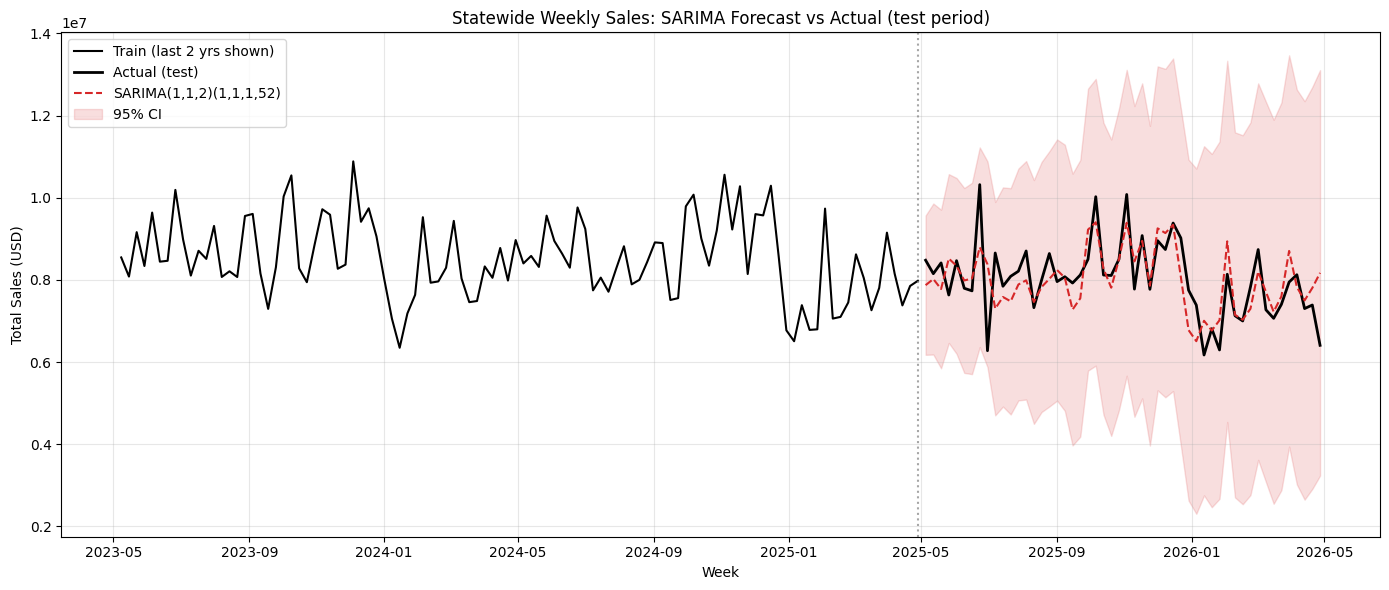

In [18]:
sarima_ci = sarima_forecast_result.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train["week_start"].iloc[-104:], y_train[-104:], label="Train (last 2 yrs shown)", color="black")
ax.plot(test["week_start"], y_test, label="Actual (test)", color="black", linewidth=2)
ax.plot(test["week_start"], sarima_fc, label="SARIMA(1,1,2)(1,1,1,52)", color="tab:red", linestyle="--")
ax.fill_between(test["week_start"], sarima_ci[:, 0], sarima_ci[:, 1], color="tab:red", alpha=0.15, label="95% CI")
ax.axvline(train["week_start"].iloc[-1], color="gray", linestyle=":", alpha=0.7)
ax.set_title("Statewide Weekly Sales: SARIMA Forecast vs Actual (test period)")
ax.set_xlabel("Week")
ax.set_ylabel("Total Sales (USD)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

**Results on the 52-week holdout (2025-05-05 to 2026-04-27):**

| Model | MAPE (%) | RMSE (USD) | MAE (USD) |
|---|---|---|---|
| SARIMA(1,1,2)(1,1,1,52) | 6.61 | 681,131 | 516,970 |
| Seasonal Naive | 8.29 | 853,805 | 638,806 |
| Naive | 8.44 | 893,160 | 667,219 |
| Drift | 9.73 | 971,342 | 746,185 |

Takeaways:

1. **SARIMA beats every baseline, on every metric, by a consistent ~20% relative
   margin.** Not a marginal win on one metric while losing another -- MAPE, RMSE, and
   MAE all improved by roughly the same amount, which is what makes this a trustworthy
   result rather than a fluke of one metric's quirks.
2. Order (1,1,2)(1,1,1,52) was selected via a 36-candidate grid search on AIC, with
   d=1, D=1, s=52 fixed from ADF/KPSS testing and ACF/PACF diagnostics -- but the exact
   p/q/P/Q came from the systematic search, not the informal plot read (which had
   suggested q=1; the search found q=2 fit better). The search corrected the manual
   guess rather than just confirming it.
3. **Numerical stability caveat, documented rather than hidden:** this model's
   coefficient standard errors showed borderline conditioning (a near-singular
   covariance matrix appeared intermittently across repeated identical fits). The point
   forecasts and AIC comparisons are trustworthy and reproducible; the exact width of
   the forecast confidence interval should be treated with some skepticism.
4. The confidence interval widens substantially later in the 52-week horizon --
   expected behavior, not a defect, but a reminder that "52-week-ahead accuracy" is an
   average across a period where later weeks are inherently less certain than earlier
   ones.

**Next steps:** Prophet (with holiday effects) and a feature-based ML model, each
evaluated on this same holdout, to see whether either beats SARIMA's 6.61% MAPE.